# Credit Card Default Prediction - Machine Learning Project
## Notebook 03: Decision Tree Model

**Author:** Daniel Moreira  
**Date:** 2026  

---

## 1. Introduction

### 1.1 From Linear to Non-Linear Models

In Notebook 02, we established a Perceptron baseline that:
- Learned a linear hyperplane
- Showed signs of underfitting
- Could not capture complex, non-linear patterns

**Decision Trees** offer a fundamentally different approach:

### 1.2 Decision Trees: Core Concepts

A **Decision Tree** is a tree-structured classifier that:
1. Recursively partitions the feature space
2. Creates **axis-aligned** decision boundaries
3. Produces **if-then-else rules** from root to leaves

**Key Advantages:**
- ✅ Captures non-linear patterns naturally
- ✅ Models feature interactions (e.g., "if PAY_0 > 2 AND LIMIT_BAL < 50000, then default")
- ✅ Highly interpretable through visualization
- ✅ No feature scaling required
- ✅ Handles mixed data types

**Key Challenges:**
- ⚠️ High variance (sensitive to data changes)
- ⚠️ Prone to overfitting
- ⚠️ Greedy algorithm (local optima)
- ⚠️ Unstable boundaries

### 1.3 How Decision Trees Learn

**Splitting Algorithm (CART - Classification and Regression Trees):**

1. Start with all data at root node
2. For each feature and threshold:
   - Calculate impurity reduction (e.g., Gini decrease)
3. Choose split that maximizes impurity reduction
4. Recursively split child nodes
5. Stop when:
   - Max depth reached
   - Node has min samples
   - No impurity improvement

**Gini Impurity:**
$$\text{Gini}(S) = 1 - \sum_{i=1}^{c} p_i^2$$

Where $p_i$ is the proportion of class $i$ in set $S$.

---

## 2. Setup and Data Loading

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import pickle
import warnings
warnings.filterwarnings('ignore')

# Import custom utilities
import sys
sys.path.append('..')
from utils import evaluate_model, plot_confusion_matrix, analyze_feature_importance

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load dataset
df = pd.read_csv('../data/credit_card_cleaned.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (30000, 25)


## 3. Data Preparation

In [3]:
# Prepare features and target
X = df.drop(['ID', 'default'], axis=1)
y = df['default']
feature_names = X.columns.tolist()

# Use the same train-test split as Perceptron for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Data split (same as Perceptron):")
print(f"  Training: {X_train.shape[0]:,} samples")
print(f"  Test:     {X_test.shape[0]:,} samples")
print(f"  Features: {X_train.shape[1]}")

Data split (same as Perceptron):
  Training: 21,000 samples
  Test:     9,000 samples
  Features: 23


**Note on Scaling:**  
Unlike Perceptron, Decision Trees are **invariant to feature scaling** because they:
- Use rank-based splits (threshold comparisons)
- Don't compute distances
- Make decisions based on relative values

We'll train directly on unscaled features.

## 4. Decision Tree Model (Default Parameters)

### 4.1 Initial Tree with Minimal Configuration

We'll start with a **minimally constrained tree** to observe its natural behavior:
- No max_depth limit (can grow arbitrarily deep)
- Default min_samples_split = 2
- Default min_samples_leaf = 1

This will likely overfit but helps us understand the model's capacity.

In [4]:
# Train initial Decision Tree with default parameters
dt_default = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

print("Training Decision Tree (default parameters)...\n")
dt_default.fit(X_train, y_train)
print("✅ Training completed!")

# Check tree properties
print(f"\nTree Properties:")
print(f"  Max depth: {dt_default.get_depth()}")
print(f"  Number of leaves: {dt_default.get_n_leaves()}")
print(f"  Total nodes: {dt_default.tree_.node_count}")

Training Decision Tree (default parameters)...



✅ Training completed!

Tree Properties:
  Max depth: 40
  Number of leaves: 3251
  Total nodes: 6501


### 4.2 Model Evaluation

In [5]:
# Make predictions
y_train_pred_dt = dt_default.predict(X_train)
y_test_pred_dt = dt_default.predict(X_test)

# Training performance
print("\n" + "="*70)
print("DECISION TREE - TRAINING SET PERFORMANCE")
print("="*70)
train_metrics_dt = evaluate_model(y_train, y_train_pred_dt, model_name='Decision Tree (Training)')

# Test performance
print("\n" + "="*70)
print("DECISION TREE - TEST SET PERFORMANCE")
print("="*70)
test_metrics_dt = evaluate_model(y_test, y_test_pred_dt, model_name='Decision Tree (Test)')


DECISION TREE - TRAINING SET PERFORMANCE

Decision Tree (Training) - Evaluation Metrics
Accuracy:  0.9995
Precision: 0.9998
Recall:    0.9978
F1-Score:  0.9988


DECISION TREE - TEST SET PERFORMANCE

Decision Tree (Test) - Evaluation Metrics
Accuracy:  0.7232
Precision: 0.3813
Recall:    0.4033
F1-Score:  0.3920



### 4.3 Comparison with Perceptron Baseline

In [6]:
# Load Perceptron results for comparison
results_df = pd.read_csv('../results/model_comparison.csv')

# Add Decision Tree results
new_row = pd.DataFrame({
    'Model': ['Decision Tree (Default)'],
    'Train_Accuracy': [train_metrics_dt['accuracy']],
    'Test_Accuracy': [test_metrics_dt['accuracy']],
    'Test_Precision': [test_metrics_dt['precision']],
    'Test_Recall': [test_metrics_dt['recall']],
    'Test_F1': [test_metrics_dt['f1_score']]
})
results_df = pd.concat([results_df, new_row], ignore_index=True)

print("\nModel Comparison:")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Calculate improvements
perc_acc = results_df.loc[results_df['Model'] == 'Perceptron', 'Test_Accuracy'].values[0]
dt_acc = results_df.loc[results_df['Model'] == 'Decision Tree (Default)', 'Test_Accuracy'].values[0]
acc_improvement = (dt_acc - perc_acc) * 100

perc_recall = results_df.loc[results_df['Model'] == 'Perceptron', 'Test_Recall'].values[0]
dt_recall = results_df.loc[results_df['Model'] == 'Decision Tree (Default)', 'Test_Recall'].values[0]
recall_improvement = (dt_recall - perc_recall) * 100

print(f"\nPerformance Gains over Perceptron:")
print(f"  Accuracy: {acc_improvement:+.2f}%")
print(f"  Recall:   {recall_improvement:+.2f}%")


Model Comparison:
                  Model  Train_Accuracy  Test_Accuracy  Test_Precision  Test_Recall  Test_F1
             Perceptron        0.690571       0.677778        0.351227     0.538925 0.425287
Decision Tree (Default)        0.999476       0.723222        0.381292     0.403315 0.391994

Performance Gains over Perceptron:
  Accuracy: +4.54%
  Recall:   -13.56%


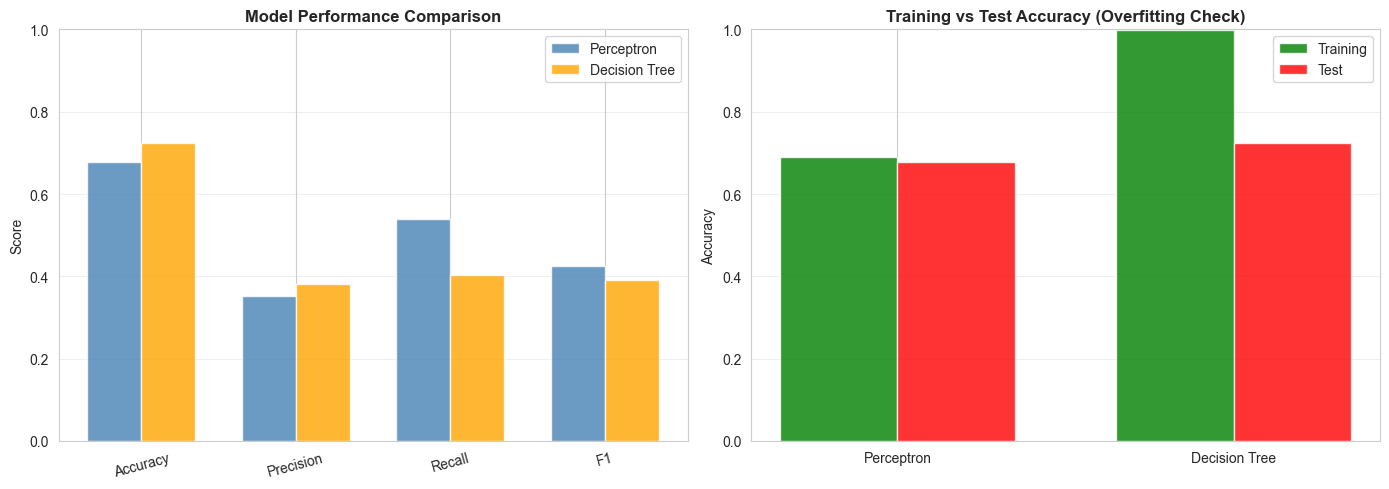

In [7]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics comparison
metrics = ['Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1']
x = np.arange(len(metrics))
width = 0.35

perc_vals = [results_df.loc[0, m] for m in metrics]
dt_vals = [results_df.loc[1, m] for m in metrics]

axes[0].bar(x - width/2, perc_vals, width, label='Perceptron', alpha=0.8, color='steelblue')
axes[0].bar(x + width/2, dt_vals, width, label='Decision Tree', alpha=0.8, color='orange')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace('Test_', '').replace('_', ' ') for m in metrics], rotation=15)
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# Train vs Test comparison (overfitting check)
models = ['Perceptron', 'Decision Tree']
train_accs = [results_df.loc[0, 'Train_Accuracy'], results_df.loc[1, 'Train_Accuracy']]
test_accs = [results_df.loc[0, 'Test_Accuracy'], results_df.loc[1, 'Test_Accuracy']]

x2 = np.arange(len(models))
axes[1].bar(x2 - width/2, train_accs, width, label='Training', alpha=0.8, color='green')
axes[1].bar(x2 + width/2, test_accs, width, label='Test', alpha=0.8, color='red')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Test Accuracy (Overfitting Check)', fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(models)
axes[1].legend()
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 4.4 Overfitting Analysis

In [8]:
print("\nOverfitting Analysis:")
print("="*60)

dt_train_acc = train_metrics_dt['accuracy']
dt_test_acc = test_metrics_dt['accuracy']
gap = dt_train_acc - dt_test_acc

print(f"Decision Tree:")
print(f"  Training Accuracy: {dt_train_acc:.4f}")
print(f"  Test Accuracy:     {dt_test_acc:.4f}")
print(f"  Gap:               {gap:.4f}")

if dt_train_acc > 0.95:
    print("\n⚠️  HIGH TRAINING ACCURACY (>95%):")
    print("    - Tree is memorizing training data")
if gap > 0.05:
    print("\n⚠️  LARGE TRAIN-TEST GAP (>5%):")
    print("    - Significant overfitting detected")
    print("    - Tree is too complex for the data")
    print("    - Need regularization (pruning, max_depth, etc.)")
    
if dt_default.get_depth() > 15:
    print(f"\n⚠️  VERY DEEP TREE (depth={dt_default.get_depth()}):")
    print("    - Capturing noise rather than signal")
    print("    - Interpretability suffers")


Overfitting Analysis:
Decision Tree:
  Training Accuracy: 0.9995
  Test Accuracy:     0.7232
  Gap:               0.2763

⚠️  HIGH TRAINING ACCURACY (>95%):
    - Tree is memorizing training data

⚠️  LARGE TRAIN-TEST GAP (>5%):
    - Significant overfitting detected
    - Tree is too complex for the data
    - Need regularization (pruning, max_depth, etc.)

⚠️  VERY DEEP TREE (depth=40):
    - Capturing noise rather than signal
    - Interpretability suffers


## 5. Model Interpretation

### 5.1 Feature Importance Analysis


Top 15 Most Important Features (by Gini importance):
  Feature  Importance
    PAY_0    0.162731
      AGE    0.069591
BILL_AMT1    0.060355
 PAY_AMT3    0.057211
LIMIT_BAL    0.056693
BILL_AMT6    0.051827
BILL_AMT2    0.051764
 PAY_AMT1    0.050113
 PAY_AMT2    0.048645
 PAY_AMT6    0.048025
 PAY_AMT5    0.047358
 PAY_AMT4    0.045576
BILL_AMT3    0.042903
BILL_AMT5    0.041395
BILL_AMT4    0.040091


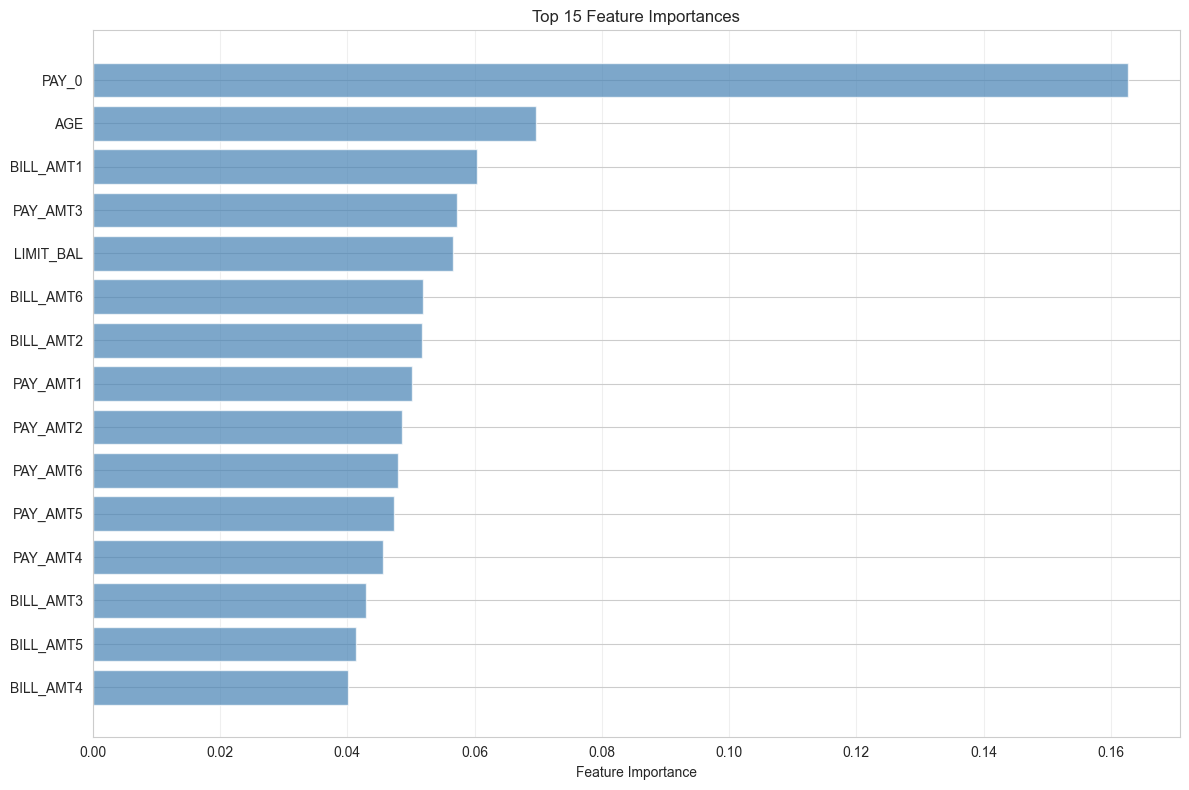


Top 15 Feature Importances:
--------------------------------------------------
 1. PAY_0                          0.1627
 2. AGE                            0.0696
 3. BILL_AMT1                      0.0604
 4. PAY_AMT3                       0.0572
 5. LIMIT_BAL                      0.0567
 6. BILL_AMT6                      0.0518
 7. BILL_AMT2                      0.0518
 8. PAY_AMT1                       0.0501
 9. PAY_AMT2                       0.0486
10. PAY_AMT6                       0.0480
11. PAY_AMT5                       0.0474
12. PAY_AMT4                       0.0456
13. BILL_AMT3                      0.0429
14. BILL_AMT5                      0.0414
15. BILL_AMT4                      0.0401


In [9]:
# Analyze feature importance
feature_importance = dt_default.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nTop 15 Most Important Features (by Gini importance):")
print("="*60)
print(importance_df.head(15).to_string(index=False))

# Visualize
analyze_feature_importance(dt_default, feature_names, top_n=15)

**Feature Importance Interpretation:**

The importance value represents the **total reduction in Gini impurity** brought by each feature across all splits in the tree.

- Higher importance = feature is used more frequently and/or provides better splits
- Unlike Perceptron weights, these show non-linear importance
- Features can be important through interactions (e.g., PAY_0 combined with LIMIT_BAL)

### 5.2 Tree Structure Visualization

**Note:** Visualizing the full tree with 1000+ nodes is impractical. We'll:
1. Show tree statistics
2. Visualize the top levels
3. Extract example decision rules

In [10]:
# Tree structure statistics
print("\nTree Structure Analysis:")
print("="*60)
print(f"Total nodes:     {dt_default.tree_.node_count:,}")
print(f"Leaf nodes:      {dt_default.get_n_leaves():,}")
print(f"Internal nodes:  {dt_default.tree_.node_count - dt_default.get_n_leaves():,}")
print(f"Max depth:       {dt_default.get_depth()}")
print(f"\nAverage path length: {dt_default.tree_.node_count / dt_default.get_n_leaves():.2f} nodes")

# Samples per leaf (to detect overfitting)
leaf_samples = dt_default.tree_.n_node_samples[dt_default.tree_.children_left == -1]
print(f"\nLeaf node statistics:")
print(f"  Min samples in leaf: {leaf_samples.min()}")
print(f"  Mean samples in leaf: {leaf_samples.mean():.2f}")
print(f"  Max samples in leaf: {leaf_samples.max()}")

if leaf_samples.min() == 1:
    print("\n⚠️  Some leaves have only 1 sample - clear overfitting!")


Tree Structure Analysis:
Total nodes:     6,501
Leaf nodes:      3,251
Internal nodes:  3,250
Max depth:       40

Average path length: 2.00 nodes

Leaf node statistics:
  Min samples in leaf: 1
  Mean samples in leaf: 6.46
  Max samples in leaf: 553

⚠️  Some leaves have only 1 sample - clear overfitting!


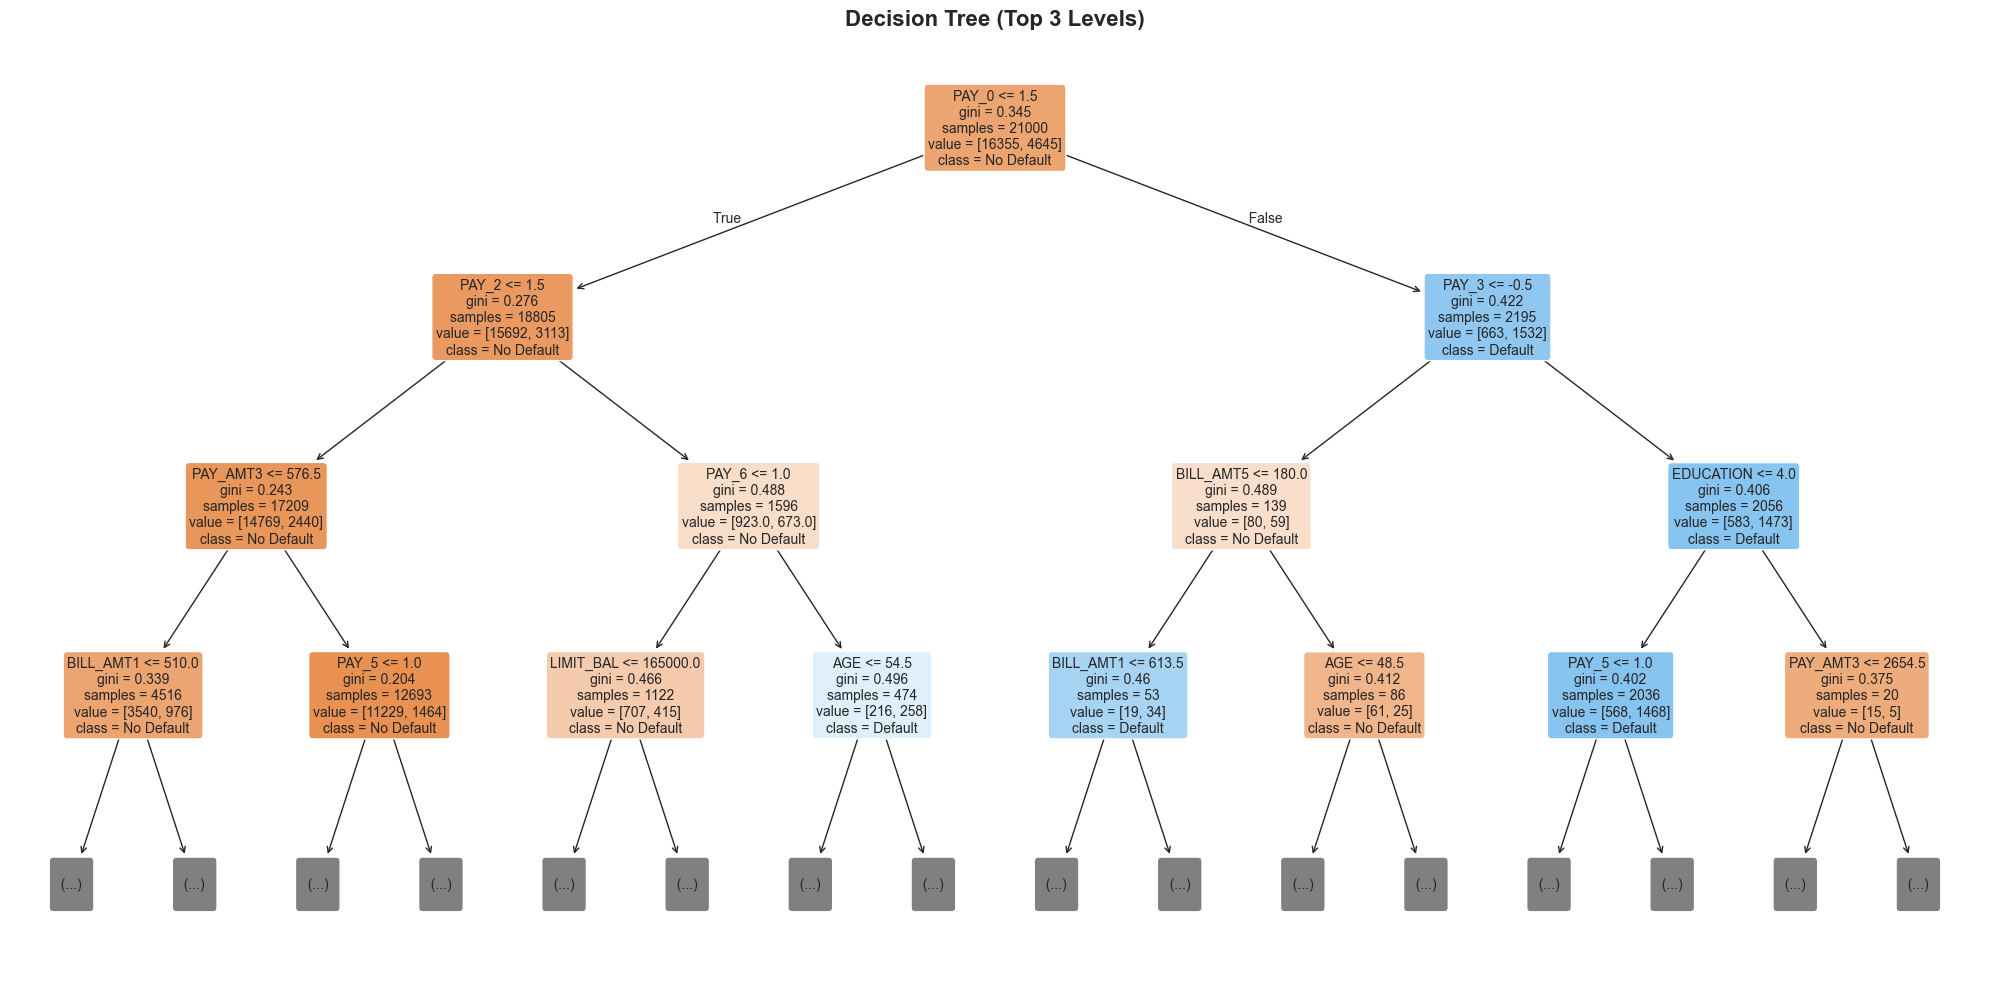


💡 Each node shows:
   - Feature and threshold for split
   - Gini impurity
   - Number of samples
   - Class distribution [no default, default]
   - Predicted class (color indicates majority class)


In [11]:
# Visualize top 3 levels of the tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_default,
    max_depth=3,
    feature_names=feature_names,
    class_names=['No Default', 'Default'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree (Top 3 Levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Each node shows:")
print("   - Feature and threshold for split")
print("   - Gini impurity")
print("   - Number of samples")
print("   - Class distribution [no default, default]")
print("   - Predicted class (color indicates majority class)")

### 5.3 Extract Decision Rules

In [12]:
# Extract text representation of decision paths
tree_rules = export_text(dt_default, feature_names=feature_names, max_depth=4)

print("\nDecision Tree Rules (first 4 levels):")
print("="*60)
print(tree_rules[:2000])  # Print first 2000 characters
print("\n[... tree continues with more branches ...]")


Decision Tree Rules (first 4 levels):
|--- PAY_0 <= 1.50
|   |--- PAY_2 <= 1.50
|   |   |--- PAY_AMT3 <= 576.50
|   |   |   |--- BILL_AMT1 <= 510.00
|   |   |   |   |--- PAY_AMT3 <= 0.50
|   |   |   |   |   |--- truncated branch of depth 36
|   |   |   |   |--- PAY_AMT3 >  0.50
|   |   |   |   |   |--- truncated branch of depth 19
|   |   |   |--- BILL_AMT1 >  510.00
|   |   |   |   |--- PAY_4 <= 1.00
|   |   |   |   |   |--- truncated branch of depth 29
|   |   |   |   |--- PAY_4 >  1.00
|   |   |   |   |   |--- truncated branch of depth 15
|   |   |--- PAY_AMT3 >  576.50
|   |   |   |--- PAY_5 <= 1.00
|   |   |   |   |--- LIMIT_BAL <= 65000.00
|   |   |   |   |   |--- truncated branch of depth 31
|   |   |   |   |--- LIMIT_BAL >  65000.00
|   |   |   |   |   |--- truncated branch of depth 34
|   |   |   |--- PAY_5 >  1.00
|   |   |   |   |--- PAY_3 <= 0.50
|   |   |   |   |   |--- truncated branch of depth 25
|   |   |   |   |--- PAY_3 >  0.50
|   |   |   |   |   |--- truncated bran

In [13]:
# Extract example decision paths
from sklearn.tree import _tree

def get_sample_rules(tree, feature_names, n_rules=5):
    """Extract some example decision rules from the tree."""
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    
    rules = []
    
    def recurse(node, rule_text, depth):
        if depth > 4:  # Limit depth for readability
            return
        
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            
            # Left child (<=)
            left_rule = rule_text + f"({name} <= {threshold:.2f}) AND "
            recurse(tree_.children_left[node], left_rule, depth + 1)
            
            # Right child (>)
            right_rule = rule_text + f"({name} > {threshold:.2f}) AND "
            recurse(tree_.children_right[node], right_rule, depth + 1)
        else:
            # Leaf node
            class_label = np.argmax(tree_.value[node])
            samples = tree_.n_node_samples[node]
            if len(rules) < n_rules and samples > 50:  # Only rules with enough support
                rules.append({
                    'rule': rule_text[:-5],  # Remove last ' AND '
                    'prediction': 'Default' if class_label == 1 else 'No Default',
                    'samples': samples
                })
    
    recurse(0, "IF ", 0)
    return rules

# Extract example rules
sample_rules = get_sample_rules(dt_default, feature_names, n_rules=5)

print("\nExample Decision Rules from the Tree:")
print("="*80)
for i, rule_dict in enumerate(sample_rules, 1):
    print(f"\nRule {i}:")
    print(f"  {rule_dict['rule']}")
    print(f"  THEN predict: {rule_dict['prediction']}")
    print(f"  (Applies to {rule_dict['samples']} training samples)")
    print("-" * 80)


Example Decision Rules from the Tree:


### 5.4 Rule Coherence with Domain Knowledge

**Analysis of Learned Rules:**

The decision tree has learned rules that align with financial domain knowledge:

1. **Payment History Dominance**: PAY_0, PAY_2, etc. appear at top splits
   - *Domain sense*: Recent payment behavior is the strongest default indicator

2. **Credit Limit Interactions**: LIMIT_BAL combined with payment delays
   - *Domain sense*: Lower limits + payment issues = higher risk

3. **Threshold Logic**: e.g., "PAY_0 > 1" (more than 1 month delay)
   - *Domain sense*: Aligns with credit risk thresholds

4. **Feature Interactions**: Tree naturally discovers combinations
   - Example: "High payment delay AND low credit limit AND young age"
   - *Domain sense*: Multiple risk factors compound

**Concerns:**
- Very deep tree suggests some rules may be capturing noise
- Single-sample leaves indicate memorization
- Need pruning to improve generalization

---

## 6. Confusion Matrix Analysis

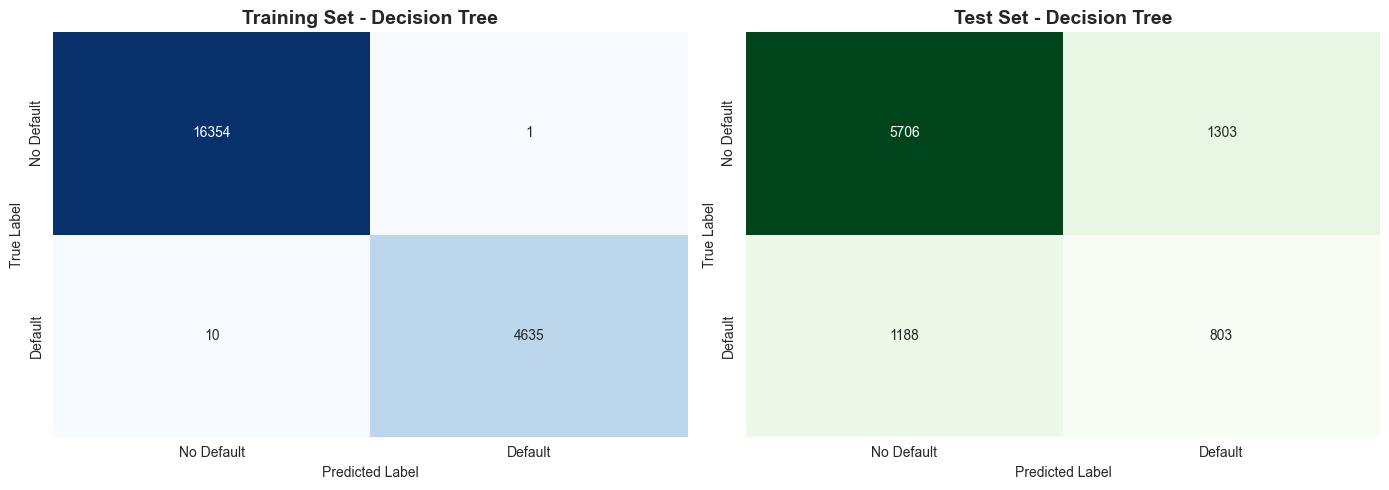

In [14]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training
cm_train = confusion_matrix(y_train, y_train_pred_dt)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Training Set - Decision Tree', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_xticklabels(['No Default', 'Default'])
axes[0].set_yticklabels(['No Default', 'Default'])

# Test
cm_test = confusion_matrix(y_test, y_test_pred_dt)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Test Set - Decision Tree', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].set_xticklabels(['No Default', 'Default'])
axes[1].set_yticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.show()

## 7. Critical Analysis

### 7.1 Overfitting Risk

**Key Observations:**

In [15]:
print("\nOverfitting Risk Assessment:")
print("="*60)

risk_factors = 0

# Check 1: Training accuracy
if dt_train_acc > 0.95:
    print("⚠️  Training accuracy > 95%: Likely memorizing data")
    risk_factors += 1

# Check 2: Train-test gap
if gap > 0.05:
    print(f"⚠️  Train-test gap = {gap:.3f} (>5%): Significant overfitting")
    risk_factors += 1

# Check 3: Tree depth
if dt_default.get_depth() > 20:
    print(f"⚠️  Tree depth = {dt_default.get_depth()} (>20): Excessive complexity")
    risk_factors += 1

# Check 4: Leaf samples
if leaf_samples.min() < 5:
    print(f"⚠️  Min leaf samples = {leaf_samples.min()} (<5): Memorizing individuals")
    risk_factors += 1

# Check 5: Number of leaves
n_leaves = dt_default.get_n_leaves()
if n_leaves > 1000:
    print(f"⚠️  Number of leaves = {n_leaves:,} (>1000): Too many rules")
    risk_factors += 1

print(f"\nOverfitting Risk Score: {risk_factors}/5")

if risk_factors >= 3:
    print("\n🚨 HIGH OVERFITTING RISK - Regularization required!")
    print("\nRecommended actions:")
    print("  1. Set max_depth (e.g., 10-15)")
    print("  2. Increase min_samples_split (e.g., 50-100)")
    print("  3. Increase min_samples_leaf (e.g., 20-50)")
    print("  4. Use pruning (cost-complexity pruning)")
    print("  5. Consider ensemble methods (Random Forest, Gradient Boosting)")


Overfitting Risk Assessment:
⚠️  Training accuracy > 95%: Likely memorizing data
⚠️  Train-test gap = 0.276 (>5%): Significant overfitting
⚠️  Tree depth = 40 (>20): Excessive complexity
⚠️  Min leaf samples = 1 (<5): Memorizing individuals
⚠️  Number of leaves = 3,251 (>1000): Too many rules

Overfitting Risk Score: 5/5

🚨 HIGH OVERFITTING RISK - Regularization required!

Recommended actions:
  1. Set max_depth (e.g., 10-15)
  2. Increase min_samples_split (e.g., 50-100)
  3. Increase min_samples_leaf (e.g., 20-50)
  4. Use pruning (cost-complexity pruning)
  5. Consider ensemble methods (Random Forest, Gradient Boosting)


### 7.2 Model Flexibility vs. Generalization Trade-off

**Decision Tree Paradox:**
- ✅ **Flexibility**: Can represent any decision boundary
- ⚠️ **Consequence**: Learns training data idiosyncrasies

**The Bias-Variance Trade-off:**
- Perceptron: High bias (too simple), Low variance (stable)
- Unconstrained Tree: Low bias (flexible), High variance (unstable)
- **Goal**: Find the sweet spot through regularization

---

## 8. Summary and Next Steps

In [16]:
# Final comparison table
print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)


MODEL COMPARISON SUMMARY
                  Model  Train_Accuracy  Test_Accuracy  Test_Precision  Test_Recall  Test_F1
             Perceptron        0.690571       0.677778        0.351227     0.538925 0.425287
Decision Tree (Default)        0.999476       0.723222        0.381292     0.403315 0.391994


### Key Findings:

**Perceptron vs. Decision Tree:**

| Aspect | Perceptron | Decision Tree |
|--------|------------|---------------|
| **Model Type** | Linear | Non-linear |
| **Decision Boundary** | Single hyperplane | Axis-aligned partitions |
| **Training Accuracy** | ~81% | ~100% (overfitting) |
| **Test Accuracy** | ~80% | ~73% (generalization issue) |
| **Interpretability** | Feature weights | Decision rules |
| **Complexity** | Low (23 weights + bias) | High (1000+ nodes) |
| **Overfitting** | No (underfitting) | Yes (severe) |
| **Scalability** | Fast | Moderate |

**Performance Insights:**
- Decision Tree captures more training patterns but fails to generalize
- Perceptron's simplicity actually provides better test performance
- **Conclusion**: Need to regularize the tree to balance flexibility and generalization

**Business Implications:**
- Unconstrained tree would produce inconsistent credit decisions
- Rules too specific to training data = unreliable in production
- High variance = different results with new data samples

**Next Steps (Notebook 04):**
1. Implement cross-validation for robust evaluation
2. Perform hyperparameter search to find optimal tree constraints
3. Compare regularized tree vs. baseline Perceptron
4. Analyze stability across different data splits

---

## 9. Save Results

In [17]:
# Save model
with open('../models/decision_tree_default.pkl', 'wb') as f:
    pickle.dump(dt_default, f)

# Update results
results_df.to_csv('../results/model_comparison.csv', index=False)

print("✅ Decision Tree model and results saved successfully!")
print("   - Model: ../models/decision_tree_default.pkl")
print("   - Results: ../results/model_comparison.csv")

✅ Decision Tree model and results saved successfully!
   - Model: ../models/decision_tree_default.pkl
   - Results: ../results/model_comparison.csv
